# Test PCA Pipeline

2/18/2026

Working on the PCA pipeline for functionality...

In [7]:
import sparkles
import sparkles.spark_xrif_pca as spca
import sparkles.spark_calibrate as spcal

import re
import datetime
import sys
import numpy as np
from importlib import reload
from matplotlib import pyplot as plt

My goal for pulling an observation is just sending in the looky loo string to parse 

### Testing the lab calib system 

In [ ]:
dark_dir = '/opt/MagAOX/calib/camwfs-dark/'
lab_dark = dark_dir + 'camwfs-dark_bin2_2000.000000_10.000000_-45.000000__T20240330051127513106835.fits'
dir_calib = "/home/eden/data/sparkPCA"

In [ ]:
lab_str_test = "2025-12-03_042134_tau_ceti_lab_efc_unsats"
amp = 0.03
hz = 2000
sep = 22
ang = 18
# n files = 5000/6000
lab_dt, lab_obs = spcal.dir_to_lookyloo(lab_str_test, target_name="tau_ceti")

In [ ]:
lab_str_test = "2025-12-01_053319_beta_pic_lab_efc"
# spark params need to be done by hand
sep = 22
amp = 0.02
ang = 45
hz = 2000
# n files = 5000/7000
lab_dt, lab_obs = spcal.dir_to_lookyloo(lab_str_test, target_name="beta_pic")

In [25]:
lab_dt

datetime.datetime(2025, 12, 1, 5, 33, 19, tzinfo=datetime.timezone.utc)

In [22]:
reload(spcal)
calib = spcal.SparkCalibrate(dir_calib, sep, ang, amp, hz)  

making directory for this calibration: /home/eden/data/sparkPCA/sep22_ang45_amp0.02_freq2000


In [23]:
calib.set_data(lab_obs, lab_dt)

['0:00:59.102844 \n', '0:02:44.278920 \n', '0:03:12.246161 \n', '0:03:06.508568 \n', '0:02:23.796118 \n', '0:03:11.945575 \n', '0:00:39.571685 \n', '0:00:50.467043 \n', '0:03:55.221355 \n', '0:05:13.609163 \n', '0:00:27.058678 \n']


In [26]:
Z_KL, Z_KL_img, lab_avgs, timing_ar = calib.gen_lab_ref(n_lab=5000)

GENERATING REFERENCE PCA basis
Found 14 xrifs, total 7168 files
PULLING 5000 FILES
FILE no 10, n_start 0, n 5000, n_offset 0
XRIF index 0, no of files 10, len list 14
file n pull (5000, 120, 120)


In [27]:
calib.save_reference()

## TEST 1: check the base pull

In [3]:
"2025-12-02_070348_beta_pic_coron_lg"

def dir_to_lookyloo(obs_str, target_name="beta_pic"):
    # searching for the lookyloo format
    m = re.match(r'^(\d{4})-(\d{2})-(\d{2})_(\d{2})(\d{2})(\d{2})_(.+)$', obs_str)
    if not m:
        raise ValueError(f"Unrecognized format: {obs_str!r}")
    # break down the date into the datetime format
    Y, M, D, hh, mm, ss, rest = m.groups()
    dt = datetime.datetime(int(Y), int(M), int(D), int(hh), int(mm), int(ss), tzinfo=datetime.timezone.utc)
    
    # take the target name out of the remaining string
    if target_name:
        # if you find this string, replace it. return what's left
        if rest.find(target_name) != -1:
            rmndr = rest.replace(target_name, "")
            return dt, rmndr[1:]
    # fallback: return the first token after the datetime
    first_token = rest.split('_')[-1]
    return dt, first_token

In [4]:
obs_str_test = "2025-12-02_070348_beta_pic_coron_lg"

dir_to_lookyloo(obs_str_test)

(datetime.datetime(2025, 12, 2, 7, 3, 48, tzinfo=datetime.timezone.utc),
 'coron_lg')

In [5]:
# TODO: update these for the most recent ones
dark_dir = '/opt/MagAOX/calib/camwfs-dark/'
lab_dark = dark_dir + 'camwfs-dark_bin2_2000.000000_10.000000_-45.000000__T20240330051127513106835.fits'
sky_dark = dark_dir + 'camwfs-dark_bin2_1800.000000_600.000000_-45.000000__T20240324234326026219038.fits'

reload(spca)
sparkPCA = spca.SparkXrif(sky_dark, lab_dark, spca.glob_dir_calib, spca.glob_mask, spca.glob_ref)

In [6]:
# then, we're going to disect the two folders I'm thinking of
obs_str_test = "2025-12-03_052203_beta_pic_piaa"
sky_dt, sky_obs = dir_to_lookyloo(obs_str_test)
print(sky_dt, sky_obs)

lab_str_test = "2025-12-03_042134_tau_ceti_lab_efc_unsats"
lab_dt, lab_obs = dir_to_lookyloo(lab_str_test, target_name="tau_ceti")
print(lab_dt, lab_obs)

2025-12-03 05:22:03+00:00 piaa
2025-12-03 04:21:34+00:00 lab_efc_unsats


In [7]:
# looking at the offset tweeter speck frames 
sparkPCA.set_data(sky_obs, lab_obs, sky_dt, lab_dt)

['0:11:54.416477 \n', '0:00:36.704347 \n', '1:41:43.488952 \n', '0:05:13.108249 \n', '0:05:06.298919 \n', '0:41:52.140625 \n', '0:05:13.880199 \n', '0:05:01.180729 \n', '0:02:59.902150 \n', '0:05:14.799356 \n', '0:01:22.063232 \n', '0:54:21.446229 \n', '0:02:04.315882 \n', '0:18:22.113603 \n', '0:05:38.846313 \n', '0:05:50.483306 \n', '0:03:22.137872 \n', '0:08:43.860726 \n', '0:57:41.425245 \n', '0:19:17.800305 \n', '0:05:06.029884 \n', '0:04:02.644722 \n', '0:02:20.588059 \n', '0:02:20.831095 \n', '0:00:57.755708 \n', '0:00:55.077337 \n', '0:00:44.271515 \n', '0:00:53.801453 \n', '0:00:36.895923 \n', '0:00:54.449253 \n', '0:00:40.595930 \n', '0:01:30.716127 \n', '0:02:08.139685 \n', '0:00:57.304783 \n', '0:02:23.744307 \n', '0:06:16.158847 \n', '0:02:23.551894 \n', '0:03:37.353735 \n', '0:00:54.954098 \n', '0:01:22.320116 \n', '0:00:42.396378 \n', '0:00:25.359113 \n', '0:00:33.400075 \n', '0:03:09.816301 \n', '0:05:02.539053 \n', '0:01:57.178315 \n', '0:01:01.501172 \n', '0:01:34.250

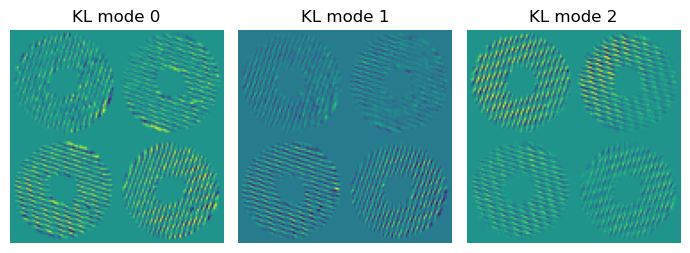

In [16]:
Z_KL_lab_images = sparkPCA.ref_pca_img
plt.figure(figsize=(7, 3))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f"KL mode {i}")
    plt.imshow(Z_KL_lab_images[i])
    plt.xticks([], [])
    plt.yticks([], [])
    plt.box(False)
#plt.suptitle(f"KL modes \n {obs_plot_name} {lab_name}")
plt.tight_layout()
plt.show()

In [9]:
dot_results = sparkPCA.proj_pool(n = 1000)

[TimestampedFile(path=PosixPath('/data/rawimages/camwfs/2025_12_03/camwfs_20251203052203614112000.xrif'), timestamp=datetime.datetime(2025, 12, 3, 5, 22, 3, 614112, tzinfo=datetime.timezone.utc)), TimestampedFile(path=PosixPath('/data/rawimages/camwfs/2025_12_03/camwfs_20251203052207710112000.xrif'), timestamp=datetime.datetime(2025, 12, 3, 5, 22, 7, 710112, tzinfo=datetime.timezone.utc)), TimestampedFile(path=PosixPath('/data/rawimages/camwfs/2025_12_03/camwfs_20251203052211806116000.xrif'), timestamp=datetime.datetime(2025, 12, 3, 5, 22, 11, 806116, tzinfo=datetime.timezone.utc)), TimestampedFile(path=PosixPath('/data/rawimages/camwfs/2025_12_03/camwfs_20251203052215902118000.xrif'), timestamp=datetime.datetime(2025, 12, 3, 5, 22, 15, 902118, tzinfo=datetime.timezone.utc)), TimestampedFile(path=PosixPath('/data/rawimages/camwfs/2025_12_03/camwfs_20251203052219998120000.xrif'), timestamp=datetime.datetime(2025, 12, 3, 5, 22, 19, 998120, tzinfo=datetime.timezone.utc)), TimestampedFile(

chunksize=1, n_workers=4
(8192, 120, 120)(8192, 120, 120)

(8192, 3)
(8192, 3)


In [10]:
data_proj = np.vstack(dot_results)

In [11]:
data_proj

array([[ 2.75077151e-08,  4.06422541e-08,  3.95980247e-08],
       [ 5.55367356e-08, -4.74809315e-08, -2.40837777e-08],
       [-2.66499800e-08,  4.80102649e-08, -2.89101619e-08],
       ...,
       [ 6.08082326e-08, -5.16751543e-08, -2.08874945e-08],
       [-2.11240916e-08,  5.01052209e-08, -2.27391424e-08],
       [-7.50601889e-08, -3.74452050e-08,  1.84050260e-08]],
      shape=(16384, 3))

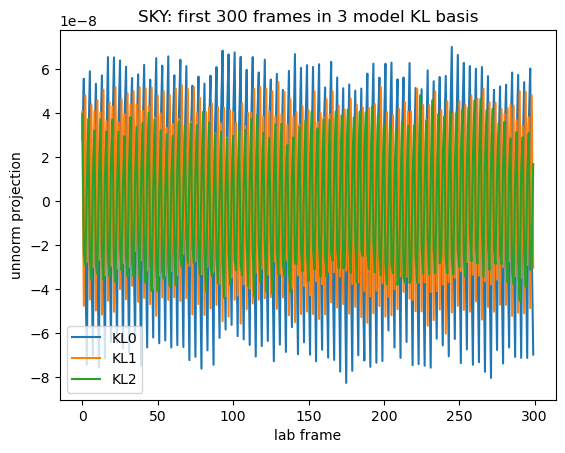

In [15]:
n = 300
plt.title(f"SKY: first {n} frames in 3 model KL basis")
for i in range(3):
    plt.plot(data_proj[:n,i], label=f"KL{i}")
plt.xlabel("lab frame")
plt.ylabel("unnorm projection")
plt.legend()
plt.show()

In [14]:
sparkPCA.ref_proj

array([[-2.86838526e-07,  4.79424850e-07, -3.75924604e-07],
       [-7.19422002e-07, -4.60414037e-07,  1.59819281e-07],
       [ 3.12319081e-07,  4.72943258e-07,  3.73246216e-07],
       [ 6.93941472e-07, -4.91953952e-07, -1.57140535e-07]])

In [75]:
n = data_proj.shape[0]
extended_divisor = np.array([np.repeat(sparkPCA.ref_proj[:,i].reshape(1,4), (n//4+1), axis=0).flatten()[:n] for i in range(3)]).T

In [73]:
extended_divisor.shape

(3, 16384)

In [80]:
data_proj / np.roll(extended_divisor, shift = 0, axis=0)

array([[-0.09589965,  0.08477294, -0.10533502],
       [-0.07719633,  0.10312659, -0.15069382],
       [-0.08532934,  0.10151379, -0.07745601],
       ...,
       [-0.08452373,  0.11223627, -0.13069446],
       [-0.06763625,  0.10594341, -0.06092263],
       [-0.10816501,  0.07611526, -0.11712462]], shape=(16384, 3))

In [62]:
extended_divisor

array([[-2.86838526e-07, -7.19422002e-07,  3.12319081e-07, ...,
        -7.19422002e-07,  3.12319081e-07,  6.93941472e-07],
       [ 4.79424850e-07, -4.60414037e-07,  4.72943258e-07, ...,
        -4.60414037e-07,  4.72943258e-07, -4.91953952e-07],
       [-3.75924604e-07,  1.59819281e-07,  3.73246216e-07, ...,
         1.59819281e-07,  3.73246216e-07, -1.57140535e-07]],
      shape=(3, 1000))

In [63]:
np.roll(extended_divisor, shift = -1, axis=1)

array([[-7.19422002e-07,  3.12319081e-07,  6.93941472e-07, ...,
         3.12319081e-07,  6.93941472e-07, -2.86838526e-07],
       [-4.60414037e-07,  4.72943258e-07, -4.91953952e-07, ...,
         4.72943258e-07, -4.91953952e-07,  4.79424850e-07],
       [ 1.59819281e-07,  3.73246216e-07, -1.57140535e-07, ...,
         3.73246216e-07, -1.57140535e-07, -3.75924604e-07]],
      shape=(3, 1000))

In [81]:
# I want the roll that minimizes the stdv
div_rolls = np.array([data_proj / np.roll(extended_divisor, shift = i, axis=0) for i in range(4)])

In [ ]:
div_rolls

In [ ]:
for i in range(3):
    plt.subplot(1,3,i)
    for i in range(4):
        plt.plot(div_rolls[i, :, 0])

In [ ]:
std_per_roll = np.std(div_rolls, axis=1) # minimized STD not consistent through rolls
mean_per_roll = np.mean(div_rolls, axis=1) # 

In [89]:
mean_per_roll

array([[-0.08720423,  0.08923442, -0.10646874],
       [-0.09095515, -0.08907271, -0.08905773],
       [ 0.08635279,  0.08862675,  0.10672797],
       [ 0.09180659, -0.08878847,  0.0887985 ]])

In [ ]:
def pick_roll(data_stack):
    '''
    Picks the roll from maximum average 
    '''
    data_allroll = np.array([split_data_dot_roll(data_stack, roll=i) for i in range(4)])
    roll_avgs = np.mean(data_allroll, axis = (1,2))
    roll_i = np.argmax(roll_avgs)
    print(f'Choosing roll index {roll_i}')
    dot_deroll = split_data_dot_roll(data_stack, roll=roll_i)
    return dot_deroll

In [55]:
# I need to make sure that I can select the right observation

# two ways to do this, put in a very specific time, or select wit the right start time

In [ ]:
# this funciton takes in an observation and turns it into a datetime


In [ ]:
lab_dark = dark_dir + 'camwfs-dark_bin2_2000.000000_10.000000_-45.000000__T20240330051127513106835.fits'
sky_dark = dark_dir + 'camwfs-dark_bin2_1800.000000_600.000000_-45.000000__T20240324234326026219038.fits'
sky_obs_name = "piaa"
lab_obs_name = "lab_efc"

spca.SparkXrif(sky_obs_name, lab_obs_name, sky_dark, lab_dark, spca.glob_dir_calib, spca.glob_mask, spca.glob_ref)

NameError: name 'sky_dark' is not defined

## TEST 2: Lab references look good